# Keras Regression Code Along Project 

Let's now apply our knowledge to a more realistic data set. Here we will also focus on feature engineering and cleaning our data!

## The Data

We will be using data from a Kaggle data set:

https://www.kaggle.com/harlfoxem/housesalesprediction

#### Feature Columns
    
* id - Unique ID for each home sold
* date - Date of the home sale
* price - Price of each home sold
* bedrooms - Number of bedrooms
* bathrooms - Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* sqft_living - Square footage of the apartments interior living space
* sqft_lot - Square footage of the land space
* floors - Number of floors
* waterfront - A dummy variable for whether the apartment was overlooking the waterfront or not
* view - An index from 0 to 4 of how good the view of the property was
* condition - An index from 1 to 5 on the condition of the apartment,
* grade - An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design.
* sqft_above - The square footage of the interior housing space that is above ground level
* sqft_basement - The square footage of the interior housing space that is below ground level
* yr_built - The year the house was initially built
* yr_renovated - The year of the house’s last renovation
* zipcode - What zipcode area the house is in
* lat - Lattitude
* long - Longitude
* sqft_living15 - The square footage of interior housing living space for the nearest 15 neighbors
* sqft_lot15 - The square footage of the land lots of the nearest 15 neighbors

In [145]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [146]:
df = pd.read_csv('D:/5 month Learning/Python for Data Science/TensorFlow_FILES/TensorFlow_FILES/DATA/kc_house_data.csv')

# Exploratory Data Analysis

In [147]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [148]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,21597.0,4.580474e+09,2.876736e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21597.0,5.402966e+05,3.673681e+05,7.800000e+04,3.220000e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21597.0,3.373200e+00,9.262989e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21597.0,2.115826e+00,7.689843e-01,5.000000e-01,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21597.0,2.080322e+03,9.181061e+02,3.700000e+02,1.430000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21597.0,1.509941e+04,4.141264e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068500e+04,1.651359e+06
floors,21597.0,1.494096e+00,5.396828e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21597.0,7.547345e-03,8.654900e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21597.0,2.342918e-01,7.663898e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21597.0,3.409825e+00,6.505456e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


<Axes: xlabel='price', ylabel='Count'>

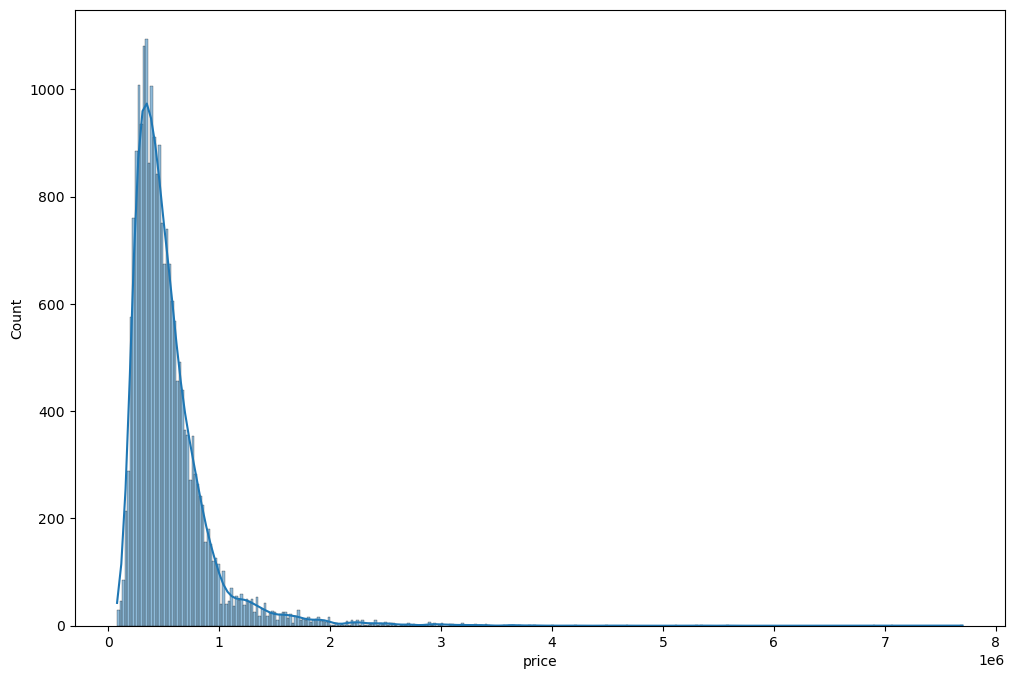

In [149]:
plt.figure(figsize=(12,8))
sns.histplot(df['price'], kde=True)

Price around 0.5 million is the most frequent in dataset, and till 2 million price the data is normal. But also dataset having price around 7 million is also there which seems outliers.

<Axes: xlabel='price', ylabel='sqft_living'>

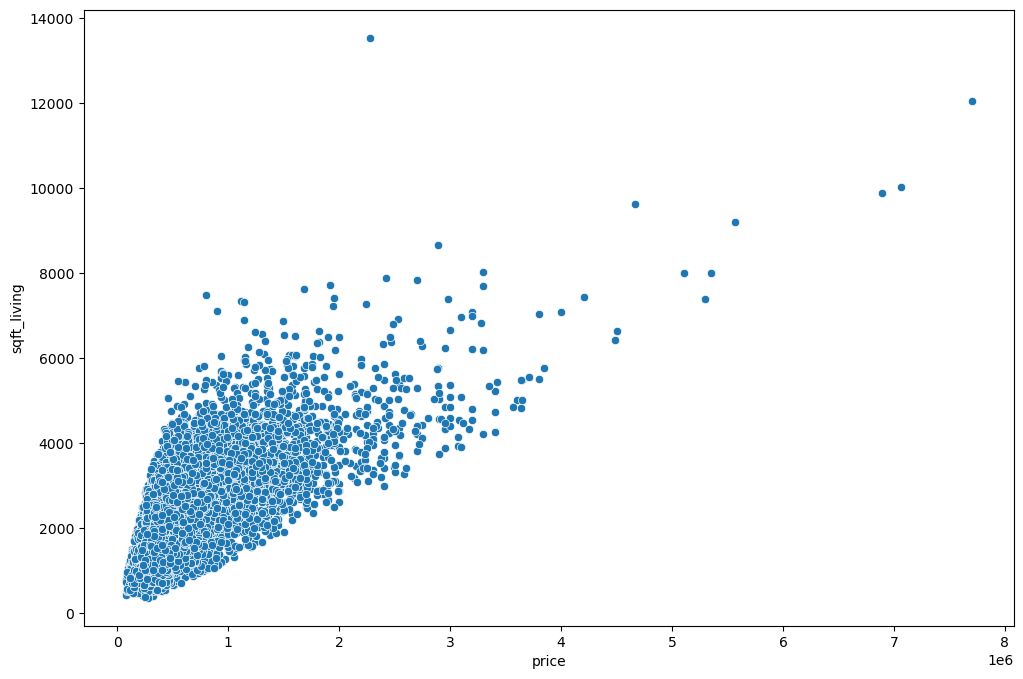

In [150]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='price',y='sqft_living',data=df)

Price having a good correlation with sqft_living, with increasing sqft_living the price is also increasing.

<Axes: xlabel='bedrooms', ylabel='price'>

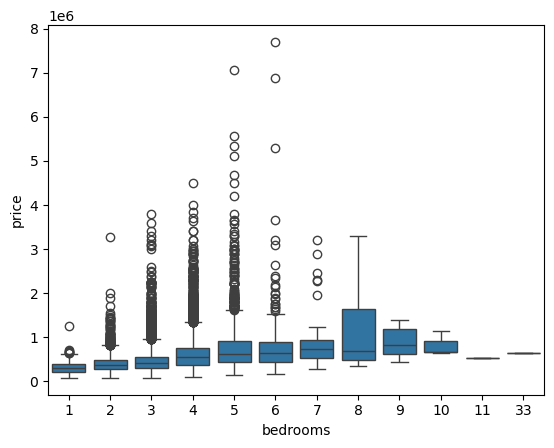

In [151]:
sns.boxplot(x = 'bedrooms',y='price', data=df)

Number of bedrooms plays a role in increasing the price of house.

### Geographical Properties

<Axes: xlabel='price', ylabel='long'>

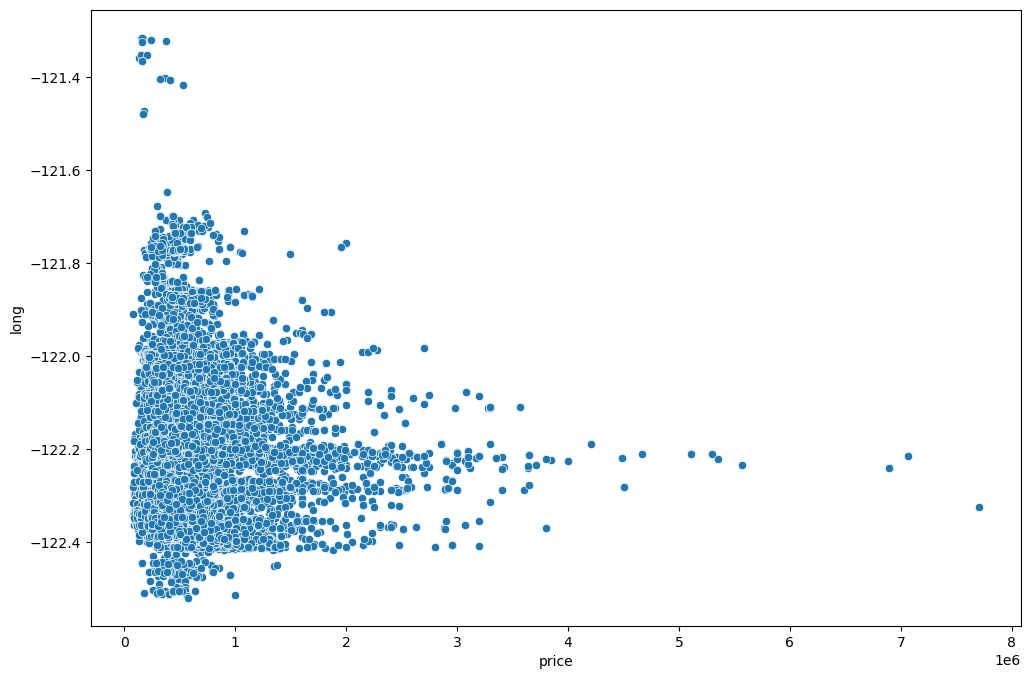

In [152]:
#plotting price vs. longitude scatterplot
plt.figure(figsize=(12,8))
sns.scatterplot(x='price',y='long',data=df)

In longitude -122.2(or around that ) the prices of house seems relatively high 

<Axes: xlabel='price', ylabel='lat'>

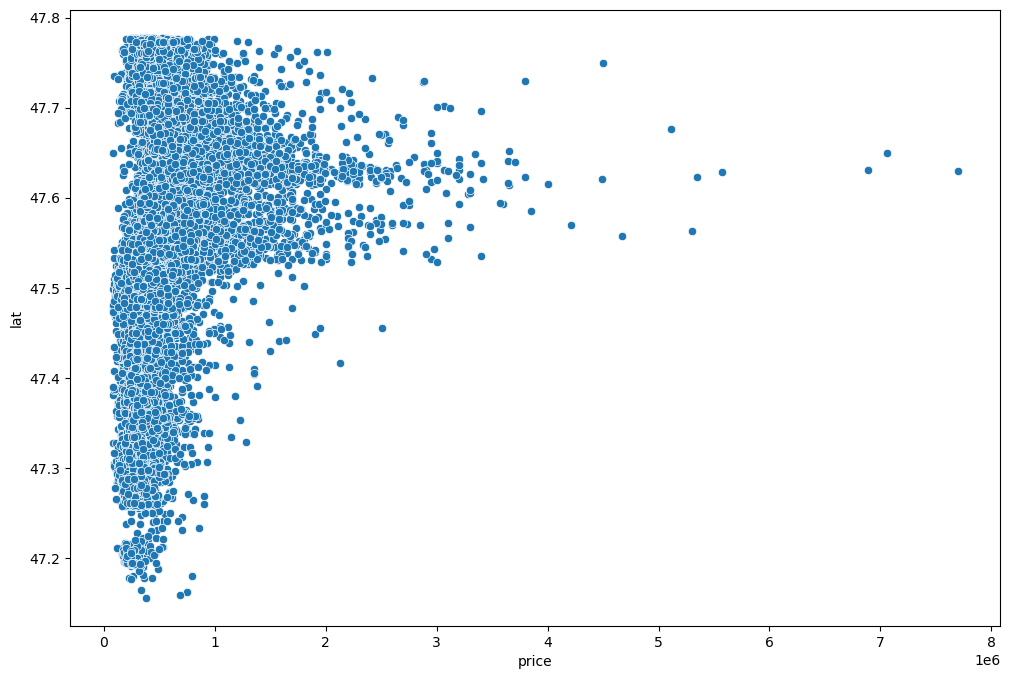

In [153]:
#plotting price vs latitude
plt.figure(figsize=(12,8))
sns.scatterplot(x='price',y='lat',data=df)

<Axes: xlabel='long', ylabel='lat'>

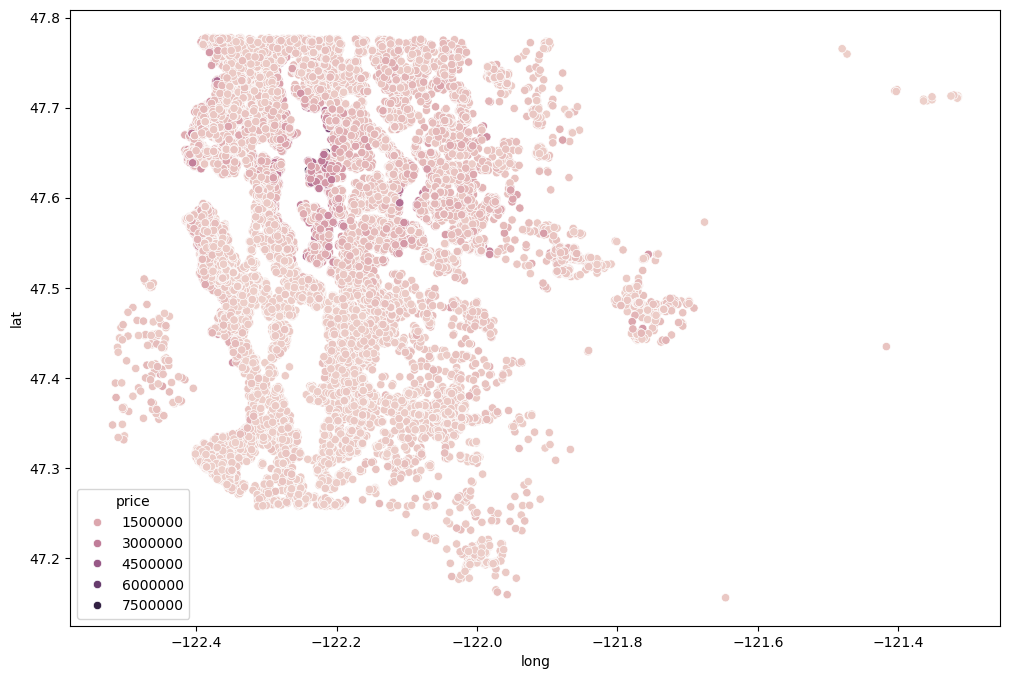

In [154]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='lat',data=df,hue='price')

This depicts a map(rough visualization) of the county, which shows that the price of the house those are beside river , are having higher price than the landlocked houses.

In [155]:
#sorting price from highest to lowest 
df.sort_values('price', ascending=False).head(20)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
7245,6762700020,10/13/2014,7700000.0,6,8.00,12050,27600,2.5,0,3,...,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
3910,9808700762,6/11/2014,7060000.0,5,4.50,10040,37325,2.0,1,2,...,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
9245,9208900037,9/19/2014,6890000.0,6,7.75,9890,31374,2.0,0,4,...,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
4407,2470100110,8/4/2014,5570000.0,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
1446,8907500070,4/13/2015,5350000.0,5,5.00,8000,23985,2.0,0,4,...,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
1313,7558700030,4/13/2015,5300000.0,6,6.00,7390,24829,2.0,1,4,...,12,5000,2390,1991,0,98040,47.5631,-122.210,4320,24619
1162,1247600105,10/20/2014,5110000.0,5,5.25,8010,45517,2.0,1,4,...,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
8085,1924059029,6/17/2014,4670000.0,5,6.75,9640,13068,1.0,1,4,...,12,4820,4820,1983,2009,98040,47.5570,-122.210,3270,10454
2624,7738500731,8/15/2014,4500000.0,5,5.50,6640,40014,2.0,1,4,...,12,6350,290,2004,0,98155,47.7493,-122.280,3030,23408
8629,3835500195,6/18/2014,4490000.0,4,3.00,6430,27517,2.0,0,0,...,12,6430,0,2001,0,98004,47.6208,-122.219,3720,14592


It shows that the dataset having some abnormal high price value ranging from 7 million to 3.5 million, after 3.5 million the data distribution seems normal. So we are going to filter top 1% of data.

In [156]:
#what would be the top 1% data from the dataset
len(df) * .01

215.97

In [157]:
non_top_1_perc = df.sort_values('price', ascending=False).iloc[216:]

<Axes: xlabel='long', ylabel='lat'>

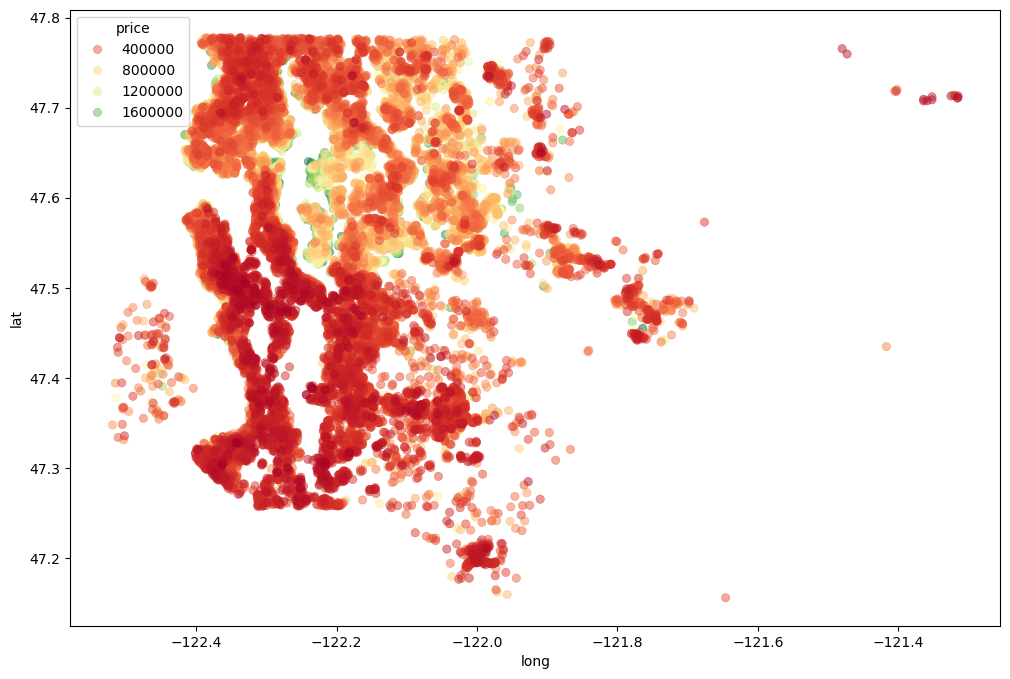

In [158]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='lat',
                data=non_top_1_perc,hue='price',
                palette='RdYlGn',edgecolor=None,alpha=0.5)

The greenspots shows the houses with high prices, which are beside the river.

<Axes: xlabel='waterfront', ylabel='price'>

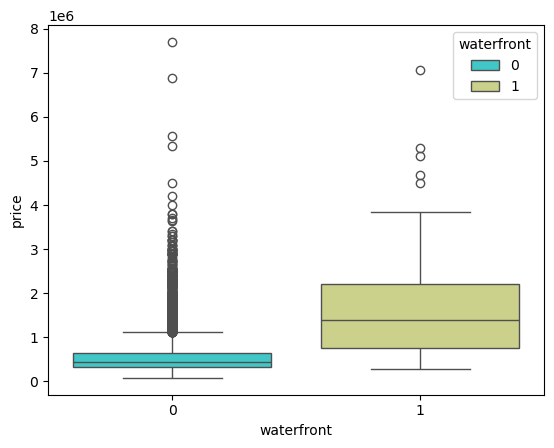

In [159]:
sns.boxplot(x='waterfront', y = 'price', data = df, hue = 'waterfront', palette='rainbow')
#which shows that waterfront houses having high prices

Working with features

In [160]:

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     21597 non-null  int64  
 9   view           21597 non-null  int64  
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21597 non-null  int64  
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   21597 non-null  int64  
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long  

In [162]:
#dropping the id column 
df = df.drop('id', axis=1)

In [163]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Feature Engineering from Date

In [164]:
df['date'] = pd.to_datetime(df['date'])

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21597 non-null  datetime64[ns]
 1   price          21597 non-null  float64       
 2   bedrooms       21597 non-null  int64         
 3   bathrooms      21597 non-null  float64       
 4   sqft_living    21597 non-null  int64         
 5   sqft_lot       21597 non-null  int64         
 6   floors         21597 non-null  float64       
 7   waterfront     21597 non-null  int64         
 8   view           21597 non-null  int64         
 9   condition      21597 non-null  int64         
 10  grade          21597 non-null  int64         
 11  sqft_above     21597 non-null  int64         
 12  sqft_basement  21597 non-null  int64         
 13  yr_built       21597 non-null  int64         
 14  yr_renovated   21597 non-null  int64         
 15  zipcode        2159

In [166]:
#extracting month from the date column
df['month'] = df['date'].apply(lambda date: date.month)

In [167]:
df["month"]

0        10
1        12
2         2
3        12
4         2
         ..
21592     5
21593     2
21594     6
21595     1
21596    10
Name: month, Length: 21597, dtype: int64

In [168]:
#extracting year from the date column
df['year'] = df['date'].apply(lambda date: date.year) 

In [169]:
df['year']

0        2014
1        2014
2        2015
3        2014
4        2015
         ... 
21592    2014
21593    2015
21594    2014
21595    2015
21596    2014
Name: year, Length: 21597, dtype: int64

<Axes: xlabel='year', ylabel='price'>

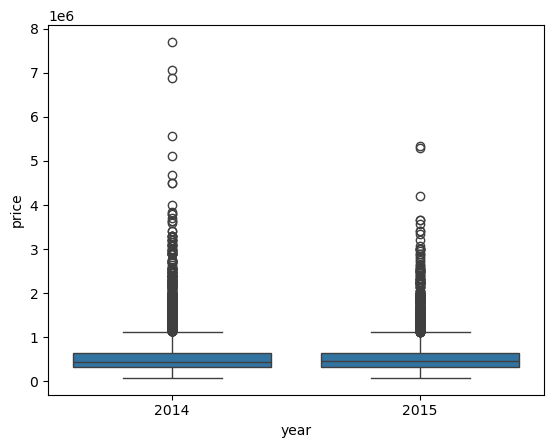

In [170]:
sns.boxplot(x='year', y = 'price', data = df)

<Axes: xlabel='month', ylabel='price'>

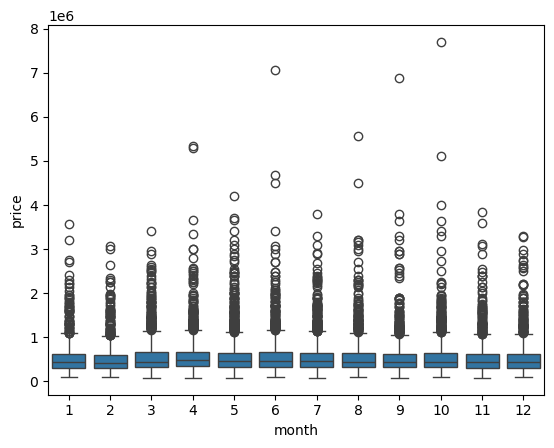

In [171]:
sns.boxplot(x='month',y='price',data=df)

<Axes: xlabel='month'>

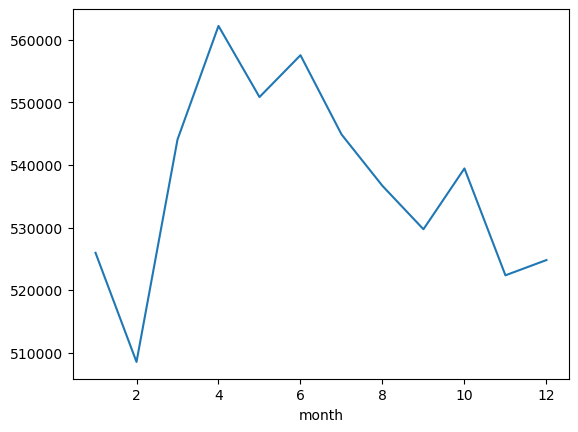

In [172]:
df.groupby('month').mean()['price'].plot()

Seems like month is not affecting that much the price 

<Axes: xlabel='year'>

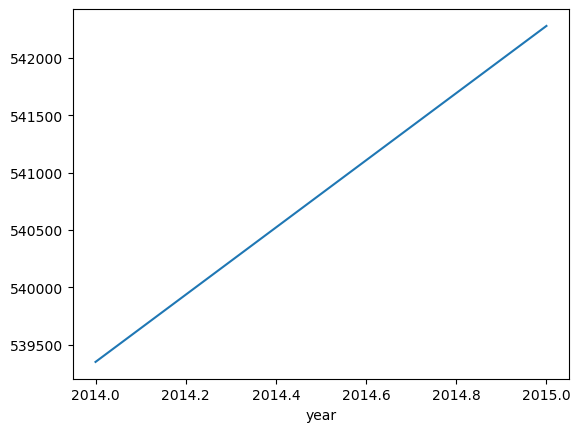

In [173]:
df.groupby('year').mean()['price'].plot()

In [174]:
#dropping the date column since we extracted data already
df = df.drop('date',axis=1)

In [175]:
df.columns


Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'month', 'year'],
      dtype='object')

In [176]:
df[['zipcode']]

,zipcode
0,98178
1,98125
2,98028
3,98136
4,98074
...,...
21592,98103
21593,98146
21594,98144
21595,98027


The zipcodes 98178 is larger than 95125, the model will learn this feature as larger number contributing more to price or like that, but thats not the actual case, zip code is just a numerical expression of the place or area, which acts like a string representation. So, we are going to drop the zipcode.

In [177]:
#analyzing zipcode if it is important or not 
df['zipcode'].value_counts()

zipcode
98103    602
98038    589
98115    583
98052    574
98117    553
        ... 
98102    104
98010    100
98024     80
98148     57
98039     50
Name: count, Length: 70, dtype: int64

In [178]:
df = df.drop('zipcode', axis = 1)

In [179]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,month,year
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650,10,2014
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639,12,2014
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062,2,2015
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000,12,2014
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503,2,2015


In [180]:
# yr_renovated feature is also works like a categorical feature, where 0 means not renovated 
df["yr_renovated"].value_counts()

yr_renovated
0       20683
2014       91
2013       37
2003       36
2005       35
        ...  
1948        1
1951        1
1959        1
1934        1
1944        1
Name: count, Length: 70, dtype: int64

In [181]:
# sqft_basement is also same , where 0 means no basement
df['sqft_basement'].value_counts()

sqft_basement
0       13110
600       221
700       218
500       214
800       206
        ...  
176         1
225         1
1275        1
274         1
248         1
Name: count, Length: 306, dtype: int64

## Scaling and Train Test Split

In [182]:
X = df.drop('price', axis = 1).values
y = df['price'].values

In [183]:
from sklearn.model_selection import train_test_split

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=101)

## Scaling

In [185]:
from sklearn.preprocessing import MinMaxScaler

In [186]:
scaler = MinMaxScaler()

In [187]:
X_train = scaler.fit_transform(X_train)

In [188]:
X_test = scaler.transform(X_test)

In [189]:
X_train.shape

(14469, 19)

In [190]:
#checking the shape to define the number of neurons in the layer
X_test.shape

(7128, 19)

## Creating a Model

In [191]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

In [192]:
#structuring the model 
model = Sequential()
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss = 'mse')


## Training the Model

In [193]:
model.fit(x = X_train, y = y_train, validation_data=(X_test, y_test), batch_size=128, epochs=400 )

Epoch 1/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 431848587264.0000 - val_loss: 416721272832.0000
Epoch 2/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 431306932224.0000 - val_loss: 414777933824.0000
Epoch 3/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 422668337152.0000 - val_loss: 394024222720.0000
Epoch 4/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 373700820992.0000 - val_loss: 309052604416.0000
Epoch 5/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 252855402496.0000 - val_loss: 169019850752.0000
Epoch 6/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 132748288000.0000 - val_loss: 98029993984.0000
Epoch 7/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 101146910720.0000 - val_loss: 93451452416.0000
Epoch 8/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 99039715328.0000 - val_loss: 92138078208.0000
Epoch 9/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 97594187776.0000 - val_loss: 90899660800.0000
Epoch 10/400
114/114 ━━━━

In [194]:
model.history.history

{'loss': [431848587264.0,
  431306932224.0,
  422668337152.0,
  373700820992.0,
  252855402496.0,
  132748288000.0,
  101146910720.0,
  99039715328.0,
  97594187776.0,
  96161472512.0,
  94645018624.0,
  93099991040.0,
  91517386752.0,
  89891028992.0,
  88223875072.0,
  86465323008.0,
  84654800896.0,
  82779389952.0,
  80822534144.0,
  78802182144.0,
  76703899648.0,
  74558644224.0,
  72314757120.0,
  70060236800.0,
  67770441728.0,
  65528422400.0,
  63349080064.0,
  61255704576.0,
  59321147392.0,
  57590489088.0,
  56061243392.0,
  54768017408.0,
  53621272576.0,
  52625154048.0,
  51797696512.0,
  51083198464.0,
  50430976000.0,
  49886601216.0,
  49337540608.0,
  48898416640.0,
  48452587520.0,
  48051896320.0,
  47639257088.0,
  47261659136.0,
  46876893184.0,
  46550339584.0,
  46148546560.0,
  45787488256.0,
  45392449536.0,
  45016350720.0,
  44680822784.0,
  44296167424.0,
  43950383104.0,
  43670593536.0,
  43343958016.0,
  43064922112.0,
  42824601600.0,
  42561114112.0,

In [195]:
losses = pd.DataFrame(model.history.history)

<Axes: >

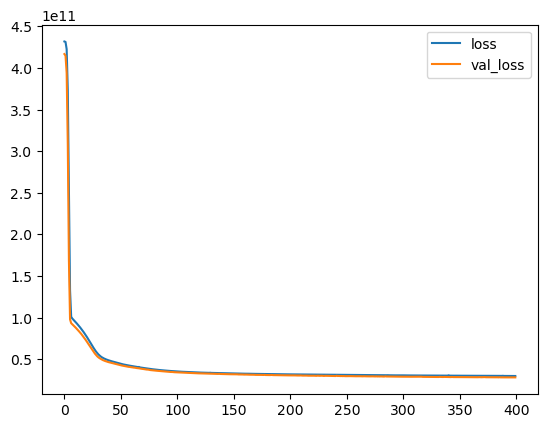

In [196]:
losses.plot()

## Evaluating on test data

In [197]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score

In [198]:
predictions = model.predict(X_test)

223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [199]:
mean_absolute_error(y_test, predictions)

103973.06439229535

In [200]:
#root mean squared error
np.sqrt(mean_squared_error(y_test, predictions))

np.float64(168316.64648078376)

In [201]:
explained_variance_score(y_test,predictions)

0.7822510499749185

In [202]:
df['price'].mean()

np.float64(540296.5735055795)

In [203]:
df['price'].median()

450000.0

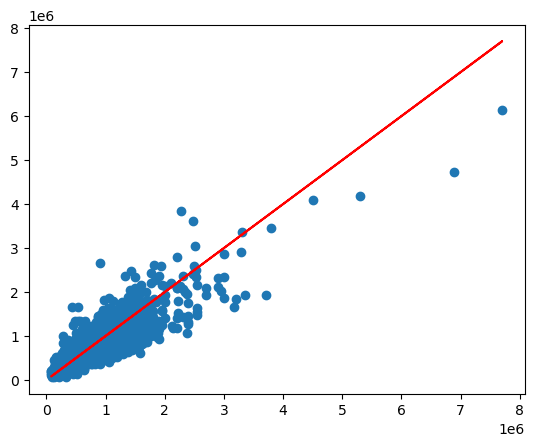

In [204]:
# Our predictions
plt.scatter(y_test,predictions)

# Perfect predictions
plt.plot(y_test,y_test,'r')

In [205]:
errors = y_test.reshape(7128, 1) - predictions


<Axes: ylabel='Count'>

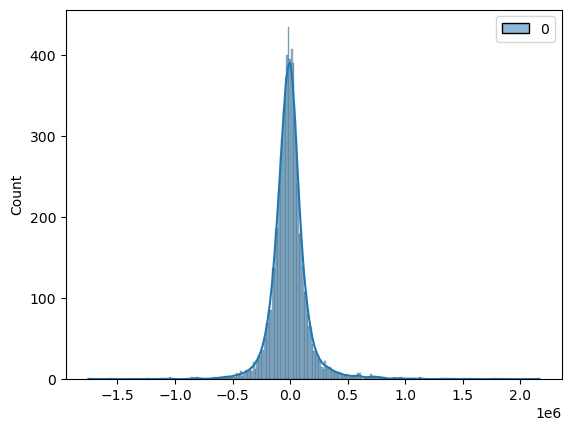

In [206]:
sns.histplot(errors,kde=True)

In [207]:
# the features of the first data sample except the price col|
single_house = df.drop('price',axis=1).iloc[0]

In [208]:
single_house = scaler.transform(single_house.values.reshape(-1, 19))


In [209]:
single_house


array([[0.2       , 0.08      , 0.08376422, 0.00310751, 0.        ,
        0.        , 0.        , 0.5       , 0.4       , 0.10785619,
        0.        , 0.47826087, 0.        , 0.57149751, 0.21760797,
        0.16193426, 0.00582059, 0.81818182, 0.        ]])

In [210]:
model.predict(single_house)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([[285773.53]], dtype=float32)

In [211]:
df.iloc[0]['price']

np.float64(221900.0)